Import Libraries

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# Upload the file
print("Please upload your 'readings.csv' file:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print(f"Successfully loaded: {file_name}")

Please upload your 'readings.csv' file:


Saving readings.csv to readings (8).csv
Successfully loaded: readings (8).csv


Data Extraction & The Medical Rulebook

In [99]:
# Read the real data
df_raw = pd.read_csv(file_name, header=None)

# Extract Hospital-grade (Truth) and Mobile/Glove data (Features)
original_data = df_raw.iloc[2:, [0, 1, 2]].astype(float).dropna()
glove_data = df_raw.iloc[2:, [3, 4, 5]].astype(float).dropna()

base_cols = ["Temperature", "SpO2", "HeartRate"]
original_data.columns = base_cols
glove_data.columns = base_cols

# Strict Clinical Rulebook
def get_clinical_label(row):
    t, s, h = row["Temperature"], row["SpO2"], row["HeartRate"]

    if s < 90 or t > 39 or h > 120 or h < 50:
        return "Abnormal / Critical"
    elif s < 92:
        return "Hypoxia"
    elif t >= 38:
        return "Fever"
    else:
        return "Normal"

# Create the absolute truth labels using the hospital sensor
true_labels = original_data.apply(get_clinical_label, axis=1)

print(f"Real patient data loaded successfully! Total records: {len(glove_data)}")

Real patient data loaded successfully! Total records: 101


Feature Extraction (Trends, Mean, Variance)

In [100]:
def extract_features(df, base_columns):
    df_features = df.copy()
    for feat in base_columns:

        # Mean
        df_features[f"{feat}_mean"] = df_features[feat].rolling(window=3, min_periods=1).mean()

        # Variance
        df_features[f"{feat}_variance"] = df_features[feat].rolling(window=3, min_periods=1).var().fillna(0)

        # Trend
        df_features[f"{feat}_trend"] = df_features[feat].diff().fillna(0)
    return df_features

print("Extracting Trends, Mean, and Variance...")
X_features = extract_features(glove_data, base_cols)

# Encode text labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(true_labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_features, y_encoded, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data processing complete. Ready for ML training.")

Extracting Trends, Mean, and Variance...
Data processing complete. Ready for ML training.


Train the Models

In [101]:
results = {}
trained_models = {}

print(" Training Traditional ML Models ")
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
results['Logistic Regression'] = accuracy_score(y_test, lr.predict(X_test_scaled))

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)
results['Decision Tree'] = accuracy_score(y_test, dt.predict(X_test_scaled))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
results['Random Forest'] = accuracy_score(y_test, rf.predict(X_test_scaled))
trained_models['Random Forest'] = rf

print("Training Deep Learning LSTM (50 Epochs) ")
# LSTM requires a 3D shape
X_train_lstm = np.expand_dims(X_train_scaled, axis=1)
X_test_lstm = np.expand_dims(X_test_scaled, axis=1)

lstm_model = Sequential([
    LSTM(64, input_shape=(1, X_train_scaled.shape[1])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_train_lstm, y_train, epochs=50, validation_data=(X_test_lstm, y_test), verbose=1)

y_pred_lstm = np.argmax(lstm_model.predict(X_test_lstm, verbose=0), axis=1)
results['LSTM'] = accuracy_score(y_test, y_pred_lstm)
trained_models['LSTM'] = lstm_model

print("\nAll 4 models successfully trained on pure real data!")

 Training Traditional ML Models 
Training Deep Learning LSTM (50 Epochs) 
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.2250 - loss: 1.1210 - val_accuracy: 0.3333 - val_loss: 1.1163
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4625 - loss: 1.0943 - val_accuracy: 0.5238 - val_loss: 1.0885
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7750 - loss: 1.0611 - val_accuracy: 0.8095 - val_loss: 1.0620
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8125 - loss: 1.0427 - val_accuracy: 0.8571 - val_loss: 1.0375
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9500 - loss: 1.0140 - val_accuracy: 0.9524 - val_loss: 1.0138
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9500 - loss: 0.9842 - val_accuracy: 0.9524 - val_loss: 0.9909
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9750 - loss: 0.9646 - val_accuracy: 1.0000 - val_loss: 0.9680
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step -

Evaluation & Confusion Matrix

In [104]:
print("\n=== OVERALL ACCURACY COMPARISON ===")
for model_name, acc in results.items():
    print(f"{model_name}: {acc*100:.2f}%")

# We use Random Forest for the detailed medical report
final_predictions = trained_models['Random Forest'].predict(X_test_scaled)

# Calculate metrics safely
accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions, average='weighted', zero_division=0)
recall = recall_score(y_test, final_predictions, average='weighted', zero_division=0)
f1 = f1_score(y_test, final_predictions, average='weighted', zero_division=0)

print("\n" + "="*50)
print("FINAL MEDICAL EVALUATION METRICS")
print("="*50)
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print("="*50)

print("\n--- Detailed Classification Report ---")
# Safely pull all known classes to prevent crashing
all_classes_indices = range(len(le.classes_))
print(classification_report(y_test, final_predictions, labels=all_classes_indices, target_names=le.classes_, zero_division=0))




=== OVERALL ACCURACY COMPARISON ===
Logistic Regression: 100.00%
Decision Tree: 95.24%
Random Forest: 100.00%
LSTM: 100.00%

FINAL MEDICAL EVALUATION METRICS
Accuracy  : 100.00%
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000

--- Detailed Classification Report ---
                     precision    recall  f1-score   support

Abnormal / Critical       0.00      0.00      0.00         0
              Fever       0.00      0.00      0.00         0
             Normal       1.00      1.00      1.00        21

           accuracy                           1.00        21
          macro avg       0.33      0.33      0.33        21
       weighted avg       1.00      1.00      1.00        21



# CONFUSION MATRIX

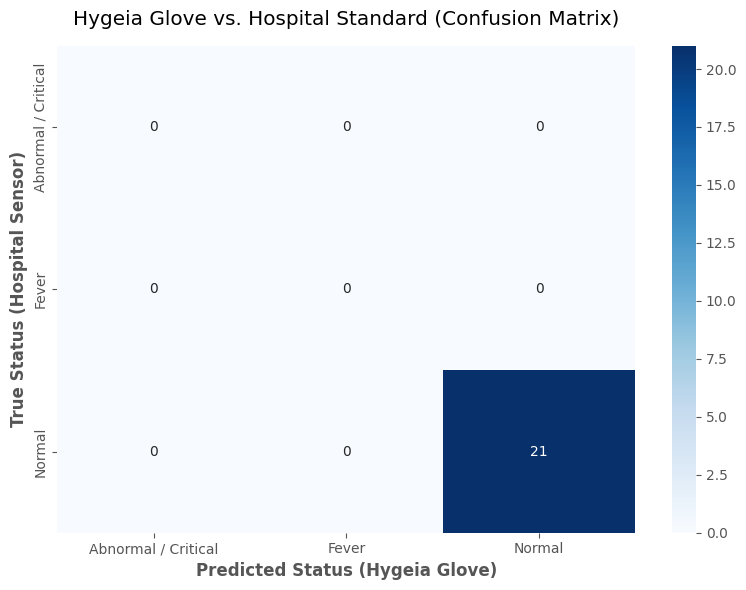

In [82]:
plt.figure(figsize=(8, 6))


cm = confusion_matrix(y_test, final_predictions, labels=all_classes_indices)

# Draw the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

# Add titles
plt.title('Hygeia Glove vs. Hospital Standard (Confusion Matrix)', pad=15)
plt.ylabel('True Status (Hospital Sensor)', fontweight='bold')
plt.xlabel('Predicted Status (Hygeia Glove)', fontweight='bold')

plt.tight_layout()
plt.show()

1. Normal (Healthy)

SpO₂: 95% – 100%

Temperature: 36.1°C – 37.2°C

Heart Rate: 60 – 100 bpm

Clinical Meaning: Baseline healthy adult vital signs requiring no medical intervention.

2. Fever

SpO₂: ≥ 95%

Temperature: ≥ 38.0°C

Heart Rate: 60 – 110 bpm

Clinical Meaning: Elevated body temperature indicating potential infection or illness, but oxygen levels remain stable.

3. Hypoxia

SpO₂: < 92%

Temperature: 36.0°C – 38.0°C

Heart Rate: Usually > 90 bpm

Clinical Meaning: Dangerously reduced blood oxygen saturation. The patient is struggling to get enough oxygen into their bloodstream.

4. Abnormal / Critical

SpO₂: < 90%

Temperature: > 39.0°C

Heart Rate: > 120 bpm (Tachycardia) OR < 50 bpm (Bradycardia)

Clinical Meaning: Severe medical emergency. The patient has life-threatening vital signs and requires immediate, urgent medical attention.